# imports

In [2]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from scipy.stats import bernoulli
import warnings
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gymnasium as gym
from gymnasium.envs.registration import register, registry, make, spec
import pickle
import copy
from itertools import product
import json
from functools import partial
from scipy.optimize import Bounds, minimize, differential_evolution
import multiprocess as mp
from pybads import BADS
import pymer4.models as pm

import IPython

import multiprocess as mp
import pingouin as pg
from scipy.special import expit

from agents import Farmer, BAMCP, CE
from utils import *
from runners import run_grid, run_bandit, run_emp, run_emp_enum
from MCTS import MonteCarloTreeSearch_AFC, MonteCarloTreeSearch_Bandit, MonteCarloTreeSearch_Emp


warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

In [59]:
room_1 = [
    [1,0,0],
    [0,1,0]
    ]
room_2 = [
    [1,0,0],
    [0, 0.5,0.5],
    ]
ells = [0.5, 1.0, 2]
for ell in ells:
    for r, room in enumerate([room_1, room_2], start=1):
        print(f"Empowerment for ell={ell} in room {r}: {env.empowerment(room, ell)}")
    print('')

Empowerment for ell=0.5 in room 1: 2.0
Empowerment for ell=0.5 in room 2: 2.414213562373095

Empowerment for ell=1.0 in room 1: 2.0
Empowerment for ell=1.0 in room 2: 2.0

Empowerment for ell=2 in room 1: 2.0
Empowerment for ell=2 in room 2: 1.5



In [354]:
## make emp env
n_arms = 2
n_outcomes = 3
n_trials = 4
alpha = 0.1
ell = 1
policy = 'uniform_tail'
policy = 'bellman'
env = make_emp_env(n_arms, n_outcomes, n_trials, alpha, ell, seed = 1)

## make agent
agent = BAMCP(
    mcts_class=MonteCarloTreeSearch_Emp, run_fn=run_emp,
    n_samples=100000,
    exploration_constant=3,
    discount_factor=1,
    horizon=1,
    temp=1,
    lapse=0,
)


run_emp_enum(agent, env, policy = policy)

initial emp: 1.0
action 0, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 0, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 0, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
  trial   1/4  Q=[1.5917 1.5917]  pulled arm 0, outcome 0, empowerment reward 1.5128
action 0, outcome 0, p(o|a,h)=0.8462, V(h u (a,o), h-1)=1.6007
action 0, outcome 1, p(o|a,h)=0.0769, V(h u (a,o), h-1)=1.5425
action 0, outcome 2, p(o|a,h)=0.0769, V(h u (a,o), h-1)=1.5425
action 1, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.1544
action 1, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.8104
action 1, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.8104
  trial   2/4  Q=[1.5917 1.5917]  pulled arm 1, outcome 2, empowerment reward 1.7692
action 0, outcome 0, p(o|a,h)=0.8462, V(h u (a,o), h-1)=1

{'Q': array([[1.59171598, 1.59171598],
        [1.59171598, 1.59171598],
        [1.81039362, 1.81039362],
        [1.80267559, 1.80267559]]),
 'p_choice': array([[0.5, 0.5],
        [0.5, 0.5],
        [0.5, 0.5],
        [0.5, 0.5]]),
 'p_repeat_choice': array([nan, 0.5, 0.5, 0.5]),
 'actions': array([0, 1, 1, 1]),
 'outcomes': array([0, 2, 1, 2]),
 'emp_improvement': array([[1.59171598, 1.59171598],
        [1.05215124, 1.05215124],
        [1.02326596, 1.02326596],
        [1.        , 1.        ]]),
 'rewards': array([1.51282051, 1.76923077, 1.80267559, 1.81585082]),
 'cumulative_reward': array([1.51282051, 3.28205128, 5.08472687, 6.90057768]),
 'true_p_matrix': array([[9.99970869e-01, 2.40825110e-36, 2.91308436e-05],
        [1.90160427e-04, 3.65830454e-01, 6.33979385e-01]]),
 'posterior_p_matrix': array([[0.84615385, 0.07692308, 0.07692308],
        [0.03030303, 0.33333333, 0.63636364]]),
 'ell': 1}

In [450]:
## ell sweep: enumerate every reachable (action, outcome) history
## for the 3-trial / 2-arm / 2-outcome empowerment bandit and record
## Q-values, P(repeat previous action), and 1-step expected
## empowerment gain.

from runners import enumerate_emp_histories

n_arms = 2
n_outcomes = 2
n_trials = 4
alpha = 1
temp = 0.1
ells = [0.33, 1.0, 3]

df = enumerate_emp_histories(
    n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials,
    alpha=alpha, ells=ells, temp=temp,
)

print(f"{len(df)} rows  ({len(ells)} ells x {len(df)//len(ells)} histories)")
df.head(70)

255 rows  (3 ells x 85 histories)


,ell,t,history,history_str,prev_action,current_emp,p_repeat,Q_0,p_0,delta_emp_0,Q_1,p_1,delta_emp_1,history_counts,history_counts_str
0,0.33,0,(),init,NaN,1.591073,NaN,1.695343,0.500000,0.079225,1.695343,0.500000,0.079225,(),
1,0.33,1,"((0, 0),)",a0o0,0.0,1.670298,0.511789,1.695343,0.511789,-0.003295,1.690627,0.488211,-0.010203,"(((0, 0), 1),)",a0o0:1
2,0.33,1,"((0, 1),)",a0o1,0.0,1.670298,0.511789,1.695343,0.511789,-0.003295,1.690627,0.488211,-0.010203,"(((0, 1), 1),)",a0o1:1
3,0.33,1,"((1, 0),)",a1o0,1.0,1.670298,0.511789,1.690627,0.488211,-0.010203,1.695343,0.511789,-0.003295,"(((1, 0), 1),)",a1o0:1
4,0.33,1,"((1, 1),)",a1o1,1.0,1.670298,0.511789,1.690627,0.488211,-0.010203,1.695343,0.511789,-0.003295,"(((1, 1), 1),)",a1o1:1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,0.33,3,"((1, 0), (1, 1), (0, 0))",a1o0-a1o1-a0o0,0.0,1.670298,0.500691,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
66,0.33,3,"((1, 0), (1, 1), (0, 1))",a1o0-a1o1-a0o1,0.0,1.670298,0.500691,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 1), 1), ((1, 0), 1), ((1, 1), 1))",a0o1:1-a1o0:1-a1o1:1
67,0.33,3,"((1, 0), (1, 1), (1, 0))",a1o0-a1o1-a1o0,1.0,1.640407,0.430163,1.666727,0.569837,0.026321,1.638608,0.430163,-0.001798,"(((1, 0), 2), ((1, 1), 1))",a1o0:2-a1o1:1
68,0.33,3,"((1, 0), (1, 1), (1, 1))",a1o0-a1o1-a1o1,1.0,1.640407,0.430163,1.666727,0.569837,0.026321,1.638608,0.430163,-0.001798,"(((1, 0), 1), ((1, 1), 2))",a1o0:1-a1o1:2


In [458]:
df.loc[df['history_counts_str']== 'a0o0:1-a1o0:1-a1o1:1']

,ell,t,history,history_str,prev_action,current_emp,p_repeat,Q_0,p_0,delta_emp_0,Q_1,p_1,delta_emp_1,history_counts,history_counts_str
32,0.33,3,"((0, 0), (1, 0), (1, 1))",a0o0-a1o0-a1o1,1.0,1.670298,0.499309,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
35,0.33,3,"((0, 0), (1, 1), (1, 0))",a0o0-a1o1-a1o0,1.0,1.670298,0.499309,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
56,0.33,3,"((1, 0), (0, 0), (1, 1))",a1o0-a0o0-a1o1,1.0,1.670298,0.499309,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
65,0.33,3,"((1, 0), (1, 1), (0, 0))",a1o0-a1o1-a0o0,0.0,1.670298,0.500691,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
71,0.33,3,"((1, 1), (0, 0), (1, 0))",a1o1-a0o0-a1o0,1.0,1.670298,0.499309,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
77,0.33,3,"((1, 1), (1, 0), (0, 0))",a1o1-a1o0-a0o0,0.0,1.670298,0.500691,1.667003,0.500691,-0.003295,1.666727,0.499309,-0.003571,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
117,1.00,3,"((0, 0), (1, 0), (1, 1))",a0o0-a1o0-a1o1,1.0,1.166667,0.500000,1.166667,0.500000,0.000000,1.166667,0.500000,0.000000,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
120,1.00,3,"((0, 0), (1, 1), (1, 0))",a0o0-a1o1-a1o0,1.0,1.166667,0.500000,1.166667,0.500000,0.000000,1.166667,0.500000,0.000000,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
141,1.00,3,"((1, 0), (0, 0), (1, 1))",a1o0-a0o0-a1o1,1.0,1.166667,0.500000,1.166667,0.500000,0.000000,1.166667,0.500000,0.000000,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1
150,1.00,3,"((1, 0), (1, 1), (0, 0))",a1o0-a1o1-a0o0,0.0,1.166667,0.500000,1.166667,0.500000,0.000000,1.166667,0.500000,0.000000,"(((0, 0), 1), ((1, 0), 1), ((1, 1), 1))",a0o0:1-a1o0:1-a1o1:1


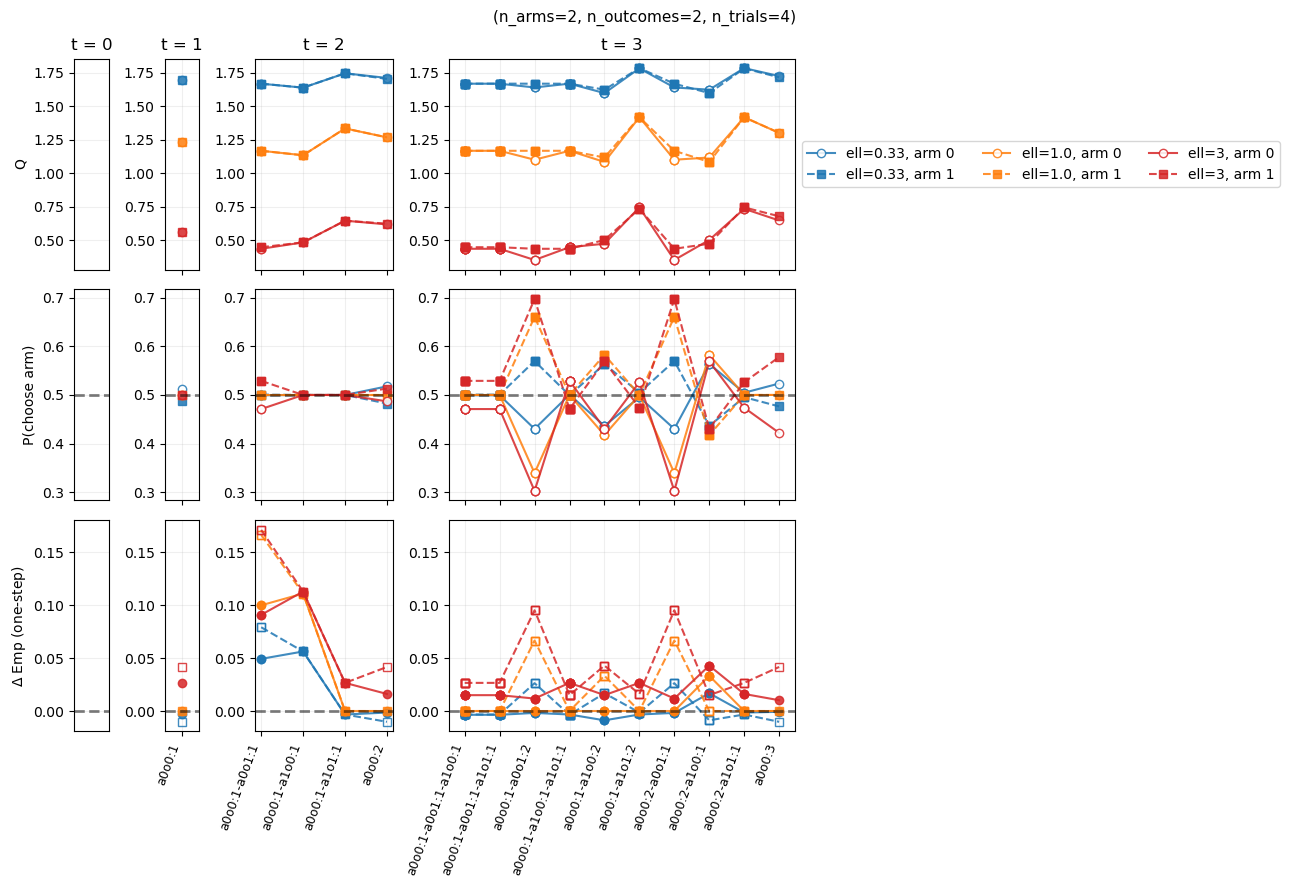

In [460]:
# plot Q, P(choice), P(repeat), and 1-step empowerment gain across the three ells.
## columns = history length t (1, 4, 16 histories), rows = metric.

import matplotlib.pyplot as plt
import numpy as np

ell_colors = {ells[0]: 'tab:blue', ells[1]: 'tab:orange', ells[2]: 'tab:red'}

x = 'history_str'
x = 'history_counts_str'

first_action_a0_only = True
first_obs_a0o0_only =  True
legend = True

def _keep_history(h):
    if first_obs_a0o0_only:
        return h == 'init' or h.startswith('a0o0')
    if first_action_a0_only:
        return h == 'init' or h.startswith('a0')
    return True

## per-t history orderings + within-t x positions
hist_by_t = {}
x_local = {}
for t in range(n_trials):
    hs = (
        df[df['t'] == t][[x]]
        .drop_duplicates()
        .sort_values(x)[x]
        .tolist()
    )
    hs = [h for h in hs if _keep_history(h)]
    hist_by_t[t] = hs
    for i, h in enumerate(hs):
        x_local[(t, h)] = i
df_plot = df[df[x].map(_keep_history)].copy()
df_plot['x_local'] = df_plot.apply(lambda r: x_local[(r['t'], r[x])], axis=1)

ts = list(range(n_trials))
n_cols = len(ts)
width_ratios = [max(1, len(hist_by_t[t])) for t in ts]

if x == 'history_str':
    n_rows = 4
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(13, 12),
        sharey='row',
        gridspec_kw={'width_ratios': width_ratios},
    )
elif x == 'history_counts_str':
    n_rows = 3
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(13, 9),
        sharey='row',
        gridspec_kw={'width_ratios': width_ratios},
    )
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

styles = ['o-', 's--', 'd:']

for j, t in enumerate(ts):
    sub_t = df_plot[df_plot['t'] == t]
    hs = hist_by_t[t]
    xs_t = list(range(len(hs)))

    ## (1) Q-values
    ax = axes[0, j]
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        markerfacecolors = ['white', str(c), str(c)]
        for a in range(n_arms):
            ax.plot(sub['x_local'], sub[f'Q_{a}'], styles[a], color=c, alpha=0.85, label=f'ell={ell}, arm {a}', markerfacecolor=markerfacecolors[a])
    ax.set_title(f't = {t}')
    if j == 0:
        ax.set_ylabel('Q')
    ax.grid(alpha=0.2)
    ax.set_xticks(xs_t)
    ax.set_xticklabels([])
    ax.tick_params(labelleft=True)
    if legend:
        if j == n_cols - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

    ## (2) Choice probabilities P(arm a)
    ax = axes[1, j]
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        markerfacecolors = ['white', str(c), str(c)]
        for a in range(n_arms):
            ax.plot(sub['x_local'], sub[f'p_{a}'], styles[a], color=c, alpha=0.85, label=f'ell={ell}, arm {a}', markerfacecolor=markerfacecolors[a])
    chance = 1 / n_arms
    ax.axhline(chance, color='k', linewidth=2, linestyle='--', alpha=0.5)
    if j == 0:
        ax.set_ylabel('P(choose arm)')
    ax.grid(alpha=0.2)
    ax.set_xticks(xs_t)
    ax.set_xticklabels([])
    ax.tick_params(labelleft=True)

    ## (3) P(repeat). Leave t=0 panel empty (no previous action) but keep
    ## the shared y-axis so the visible scale matches the data panels.
    if x == 'history_str':
        ax = axes[2, j]
        if t == 0:
            ax.text(0.5, 0.5, 'no previous action',
                    ha='center', va='center', transform=ax.transAxes,
                    color='grey', fontsize=10, rotation=90)
            ax.set_xticks([])
        else:
            for ell in ells:
                sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
                ax.plot(sub['x_local'], sub['p_repeat'], 'o-',
                        color=ell_colors[ell], alpha=0.85, label=f'ell={ell}')
            chance = 1 / n_arms
            ax.axhline(chance, color='k', linewidth=2, linestyle='--', alpha=0.5)
            ax.set_xticks(xs_t)
            ax.set_xticklabels([])
        ax.grid(alpha=0.2)
        ax.tick_params(labelleft=True)
        if j == 0:
            ax.set_ylabel('P(repeat previous action)')

    ## (4) 1-step expected empowerment gain
    ax = axes[-1, j]
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        ax.plot(sub['x_local'], sub['delta_emp_0'], 'o-', color=c, alpha=0.85,
                label=f'ell={ell}, arm 0')
        ax.plot(sub['x_local'], sub['delta_emp_1'], 's--', color=c, alpha=0.85,
                label=f'ell={ell}, arm 1', markerfacecolor='none')
    ax.set_xticks(xs_t)
    ax.set_xticklabels(hs, rotation=70, ha='right', fontsize=9)
    ax.grid(alpha=0.2)
    ax.tick_params(labelleft=True)
    ax.axhline(0, color='k', linewidth=2, linestyle='--', alpha=0.5)
    if j == 0:
        ax.set_ylabel(r'$\Delta$ Emp (one-step)')

fig.suptitle(
    f'(n_arms={n_arms}, n_outcomes={n_outcomes}, n_trials={n_trials})',
    fontsize=11,
)
plt.tight_layout()
plt.show()